In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
dataset = pd.read_csv("spam_ham_dataset.csv")
dataset = dataset.drop(columns=["label_num", "Unnamed: 0"], axis=1)
dataset.head()

,label,text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

dataset["label"] = le.fit_transform(dataset["label"])
dataset.head()

,label,text
0,0,Subject: enron methanol ; meter # : 988291\r\n...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,1,"Subject: photoshop , windows , office . cheap ..."
4,0,Subject: re : indian springs\r\nthis deal is t...


In [30]:
dataset.isna().sum()

label    0
text     0
dtype: int64

In [31]:
print(dataset.duplicated().sum())
dataset = dataset.drop_duplicates(keep='first')

178


In [32]:
dataset.duplicated().sum()


np.int64(0)

In [33]:
dataset.head()

,label,text
0,0,Subject: enron methanol ; meter # : 988291\r\n...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,1,"Subject: photoshop , windows , office . cheap ..."
4,0,Subject: re : indian springs\r\nthis deal is t...


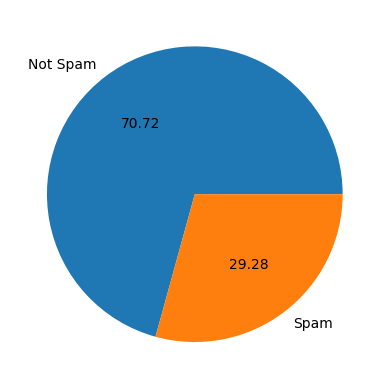

In [34]:
plt.pie(dataset["label"].value_counts(), labels=["Not Spam", "Spam"], autopct="%0.2f")
plt.show()

In [35]:
import nltk

In [36]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [37]:
df = dataset
df.head()

,label,text
0,0,Subject: enron methanol ; meter # : 988291\r\n...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,1,"Subject: photoshop , windows , office . cheap ..."
4,0,Subject: re : indian springs\r\nthis deal is t...


In [38]:
df['num_char'] = df['text'].apply(len)
df.head()

,label,text,num_char
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524
3,1,"Subject: photoshop , windows , office . cheap ...",414
4,0,Subject: re : indian springs\r\nthis deal is t...,336


In [39]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,label,text,num_char,num_words
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551
3,1,"Subject: photoshop , windows , office . cheap ...",414,49
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71


In [40]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,label,text,num_char,num_words,num_sentences
0,0,Subject: enron methanol ; meter # : 988291\r\n...,327,68,3
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",97,24,3
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",2524,551,24
3,1,"Subject: photoshop , windows , office . cheap ...",414,49,3
4,0,Subject: re : indian springs\r\nthis deal is t...,336,71,3


In [41]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

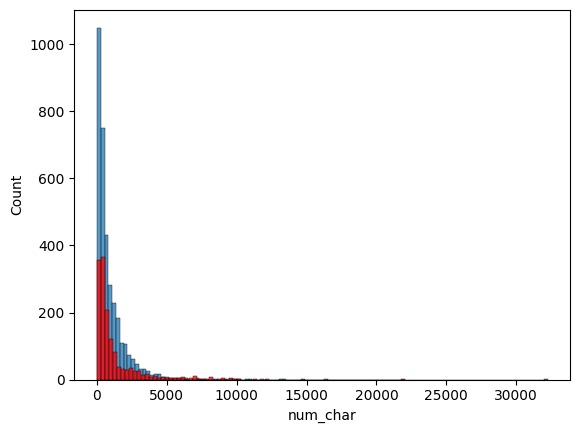

In [42]:
sns.histplot(dataset[dataset["label"] == 0]['num_char'])
sns.histplot(dataset[dataset["label"] == 1]['num_char'], color="red")

In [43]:
dataset.columns

Index(['label', 'text', 'num_char', 'num_words', 'num_sentences'], dtype='object')

<Axes: >

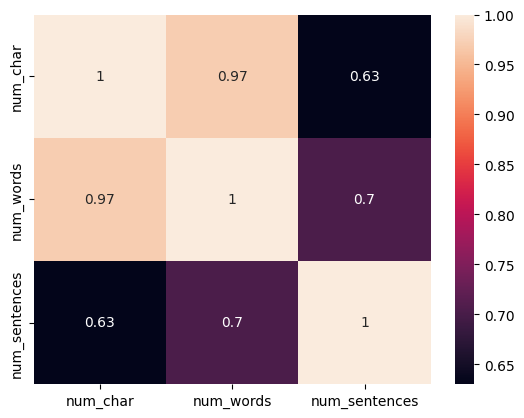

In [44]:
sns.heatmap(dataset[['num_char', 'num_words', 'num_sentences']].corr(), annot=True)

In [45]:
def lower_text(string):
    string = string.apply(lambda x: x.lower())

    return string

In [46]:
def create_tokens(string):
    return string.apply(lambda x: nltk.word_tokenize(x))


In [47]:
def remove_special(tokens):
    return tokens.apply(lambda tokens: [i for i in tokens if i.isalnum()])


In [48]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(refined):
    return refined.apply(lambda words: [i for i in words if i not in stop_words])

In [49]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

def use_stem(string):
    return string.apply(lambda base_word: [stemmer.stem(i) for i in base_word ])

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

data_pipeline = Pipeline([
    ('lowercase', FunctionTransformer(lower_text)),
    ('tokenize_words', FunctionTransformer(create_tokens)),
    ('remove_special', FunctionTransformer(remove_special)),
    ('remove_stopwords', FunctionTransformer(remove_stopwords)),
    ('Use_PorterStemmer', FunctionTransformer(use_stem))
])

In [51]:
df["transformed_text"] = data_pipeline.fit_transform(df['text'])
df['transformed_text'] = df['transformed_text'].apply(' '.join)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text'])
y = df['label']

SyntaxError: 'return' outside function (537065179.py, line 8)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

svm = LinearSVC(max_iter=1000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n\t\t\t\t\t-:- For Logistic Regression -:-\n")
print(f"The Accuracy Score is: \n {accuracy_score(y_test, y_pred_lr)}")
print(f"\nThe Confusion Matrix is: \n {confusion_matrix(y_test, y_pred_lr)}")
print(f"\nThe Classification Report is: \n {classification_report(y_test, y_pred_lr)}")

print("\t\t\t\t\t-:- For Multinomial Naive Bayes -:-\n")
print(f"The Accuracy Score is: \n {accuracy_score(y_test, y_pred_nb)}")
print(f"\nThe Confusion Matrix is: \n {confusion_matrix(y_test, y_pred_nb)}")
print(f"\nThe Classification Report is: \n {classification_report(y_test, y_pred_nb)}")

print("\t\t\t\t\t-:- For Linear Support Vector Classifier -:-\n")
print(f"The Accuracy Score is: \n {accuracy_score(y_test, y_pred_svm)}")
print(f"\nThe Confusion Matrix is: \n {confusion_matrix(y_test, y_pred_svm)}")
print(f"\nThe Classification Report is: \n {classification_report(y_test, y_pred_svm)}")

In [ ]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'MultinomialNB': accuracy_score(y_test, y_pred_nb),
    'LinearSVC': accuracy_score(y_test, y_pred_svm)
}

best_model = max(results, key=results.get)
print(f"Best Model: {best_model} with accuracy {results[best_model]:.4f}")

In [ ]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('models/nb_model.pkl', 'wb') as f:
    pickle.dump(nb, f)

with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('models/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Saved: lr, nb, svm, tfidf")